In [1]:
from numpy import where
from collections import Counter
from sklearn.datasets import make_classification
from matplotlib import pyplot

(1000, 2) (1000,)
Counter({0: 983, 1: 17})
[0.86924745 1.18613612] 0
[1.55110839 1.81032905] 0
[1.29361936 1.01094607] 0
[1.11988947 1.63251786] 0
[1.04235568 1.12152929] 0
[1.18114858 0.92397607] 0
[1.1365562  1.17652556] 0
[0.46291729 0.72924998] 0
[0.18315826 1.07141766] 0
[0.32411648 0.53515376] 0


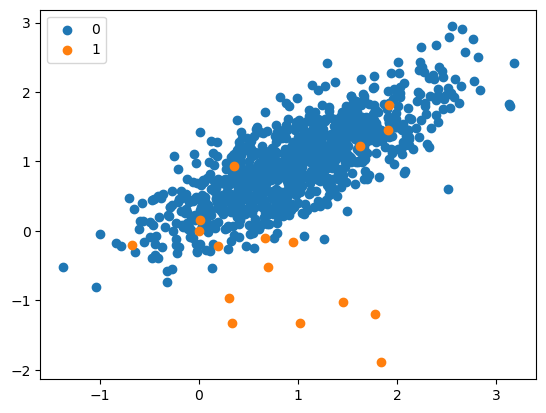

In [2]:
# example of an imbalanced binary classification task

# define dataset
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, n_classes=2, n_clusters_per_class=1, weights=[0.99,0.01], random_state=1)
# summarize dataset shape
print(X.shape, y.shape)
# summarize observations by class label
counter = Counter(y)
print(counter)
# summarize first few examples
for i in range(10):
 print(X[i], y[i])
# plot the dataset and color the by class label
for label, _ in counter.items():
 row_ix = where(y == label)[0]
 pyplot.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
pyplot.legend()
pyplot.show()

In [23]:
from sklearn.model_selection import GridSearchCV, train_test_split
# example of manually specifying the loss function for multi-class classification
from sklearn.datasets import make_classification
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, RocCurveDisplay
from sklearn.metrics import accuracy_score, roc_auc_score
# define dataset
X, y = make_classification(n_samples=10000, n_features=20, n_informative=15, n_redundant=5, random_state=1, n_classes=3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [24]:
# define the model
model = XGBClassifier(objective="multi:softprob")
# fit the model
model.fit(X_train, y_train)
# summarize the model loss function
print(model.objective)

multi:softprob


In [27]:
y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)
roc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
print(f"Test ROC: {roc}")
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy}")
# RocCurveDisplay.from_predictions( y_test, y_pred_prob, multi_class='ovr')


Test ROC: 0.9897593247901373
Test Accuracy: 0.939


## Example Target Variable Transformation:

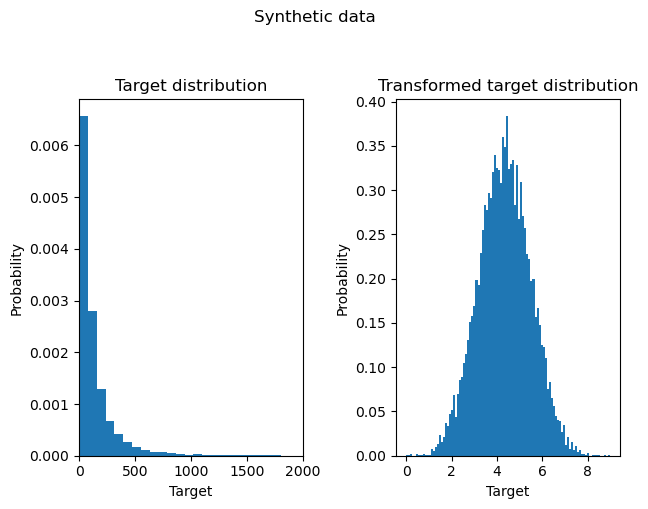

In [28]:
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

X, y = make_regression(n_samples=10_000, noise=100, random_state=0)
y = np.expm1((y + abs(y.min())) / 200)
y_trans = np.log1p(y)

f, (ax0, ax1) = plt.subplots(1, 2)

ax0.hist(y, bins=100, density=True)
ax0.set_xlim([0, 2000])
ax0.set_ylabel("Probability")
ax0.set_xlabel("Target")
ax0.set_title("Target distribution")

ax1.hist(y_trans, bins=100, density=True)
ax1.set_ylabel("Probability")
ax1.set_xlabel("Target")
ax1.set_title("Transformed target distribution")

f.suptitle("Synthetic data", y=1.05)
plt.tight_layout()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [29]:
from sklearn.metrics import median_absolute_error, r2_score


def compute_score(y_true, y_pred):
    return {
        "R2": f"{r2_score(y_true, y_pred):.3f}",
        "MedAE": f"{median_absolute_error(y_true, y_pred):.3f}",
    }

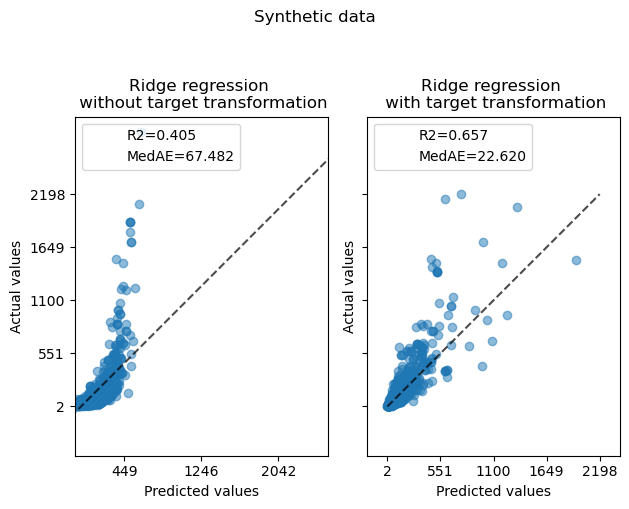

In [30]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import PredictionErrorDisplay

f, (ax0, ax1) = plt.subplots(1, 2, sharey=True)

ridge_cv = RidgeCV().fit(X_train, y_train)
y_pred_ridge = ridge_cv.predict(X_test)

ridge_cv_with_trans_target = TransformedTargetRegressor(
    regressor=RidgeCV(), func=np.log1p, inverse_func=np.expm1
).fit(X_train, y_train)
y_pred_ridge_with_trans_target = ridge_cv_with_trans_target.predict(X_test)

PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred_ridge,
    kind="actual_vs_predicted",
    ax=ax0,
    scatter_kwargs={"alpha": 0.5},
)
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred_ridge_with_trans_target,
    kind="actual_vs_predicted",
    ax=ax1,
    scatter_kwargs={"alpha": 0.5},
)

# Add the score in the legend of each axis
for ax, y_pred in zip([ax0, ax1], [y_pred_ridge, y_pred_ridge_with_trans_target]):
    for name, score in compute_score(y_test, y_pred).items():
        ax.plot([], [], " ", label=f"{name}={score}")
    ax.legend(loc="upper left")

ax0.set_title("Ridge regression \n without target transformation")
ax1.set_title("Ridge regression \n with target transformation")
f.suptitle("Synthetic data", y=1.05)
plt.tight_layout()

### Real World Data Set

In [31]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import quantile_transform

ames = fetch_openml(name="house_prices", as_frame=True)
# Keep only numeric columns
X = ames.data.select_dtypes(np.number)
# Remove columns with NaN or Inf values
X = X.drop(columns=["LotFrontage", "GarageYrBlt", "MasVnrArea"])
# Let the price be in k$
y = ames.target / 1000
y_trans = quantile_transform(
    y.to_frame(), n_quantiles=900, output_distribution="normal", copy=True
).squeeze()

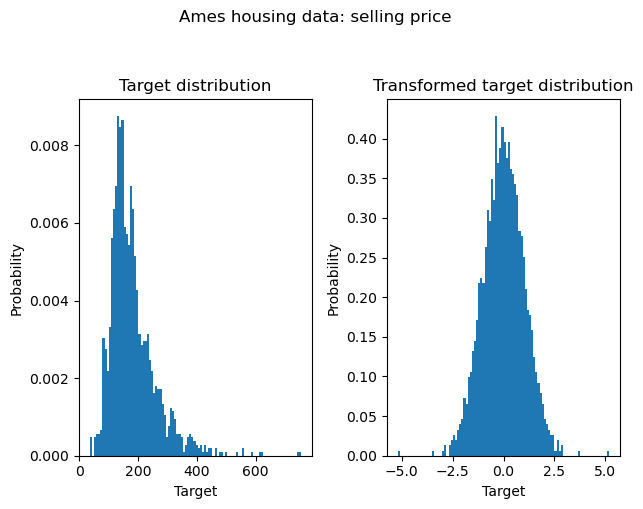

In [32]:
f, (ax0, ax1) = plt.subplots(1, 2)

ax0.hist(y, bins=100, density=True)
ax0.set_ylabel("Probability")
ax0.set_xlabel("Target")
ax0.set_title("Target distribution")

ax1.hist(y_trans, bins=100, density=True)
ax1.set_ylabel("Probability")
ax1.set_xlabel("Target")
ax1.set_title("Transformed target distribution")

f.suptitle("Ames housing data: selling price", y=1.05)
plt.tight_layout()

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

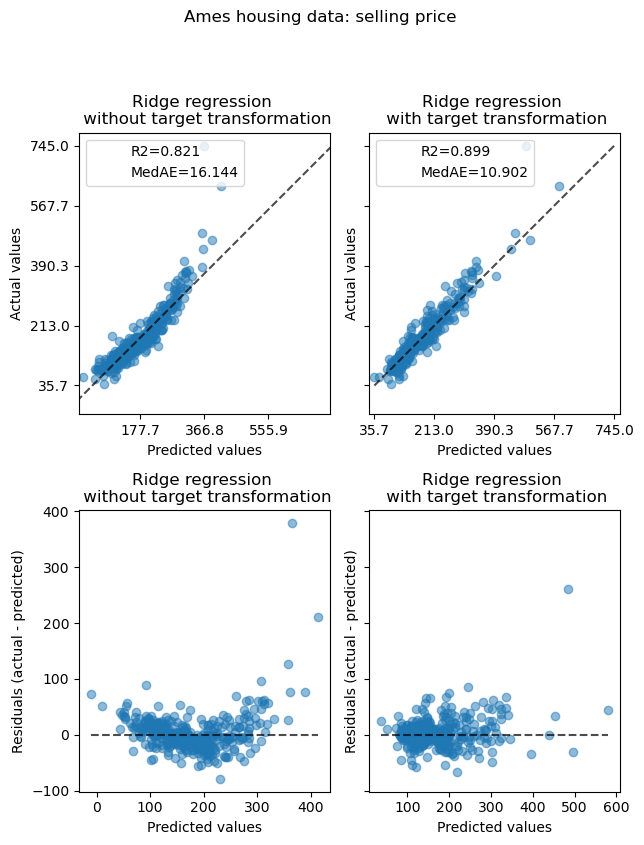

In [34]:
from sklearn.preprocessing import QuantileTransformer

f, (ax0, ax1) = plt.subplots(2, 2, sharey="row", figsize=(6.5, 8))

ridge_cv = RidgeCV().fit(X_train, y_train)
y_pred_ridge = ridge_cv.predict(X_test)

ridge_cv_with_trans_target = TransformedTargetRegressor(
    regressor=RidgeCV(),
    transformer=QuantileTransformer(n_quantiles=900, output_distribution="normal"),
).fit(X_train, y_train)
y_pred_ridge_with_trans_target = ridge_cv_with_trans_target.predict(X_test)

# plot the actual vs predicted values
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred_ridge,
    kind="actual_vs_predicted",
    ax=ax0[0],
    scatter_kwargs={"alpha": 0.5},
)
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred_ridge_with_trans_target,
    kind="actual_vs_predicted",
    ax=ax0[1],
    scatter_kwargs={"alpha": 0.5},
)

# Add the score in the legend of each axis
for ax, y_pred in zip([ax0[0], ax0[1]], [y_pred_ridge, y_pred_ridge_with_trans_target]):
    for name, score in compute_score(y_test, y_pred).items():
        ax.plot([], [], " ", label=f"{name}={score}")
    ax.legend(loc="upper left")

ax0[0].set_title("Ridge regression \n without target transformation")
ax0[1].set_title("Ridge regression \n with target transformation")

# plot the residuals vs the predicted values
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred_ridge,
    kind="residual_vs_predicted",
    ax=ax1[0],
    scatter_kwargs={"alpha": 0.5},
)
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred_ridge_with_trans_target,
    kind="residual_vs_predicted",
    ax=ax1[1],
    scatter_kwargs={"alpha": 0.5},
)
ax1[0].set_title("Ridge regression \n without target transformation")
ax1[1].set_title("Ridge regression \n with target transformation")

f.suptitle("Ames housing data: selling price", y=1.05)
plt.tight_layout()
plt.show()

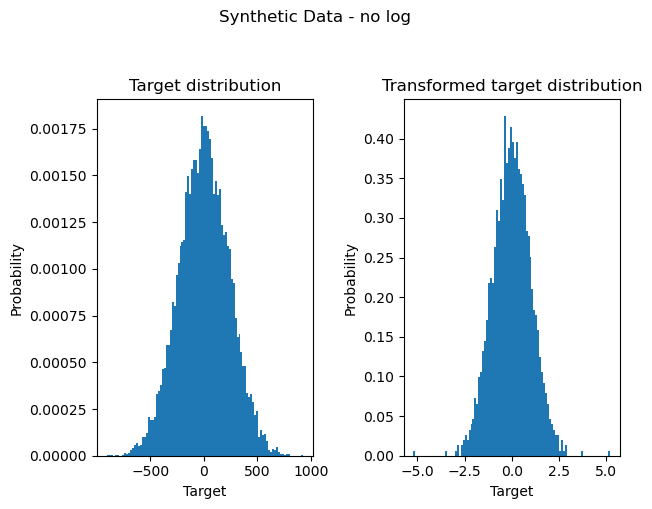

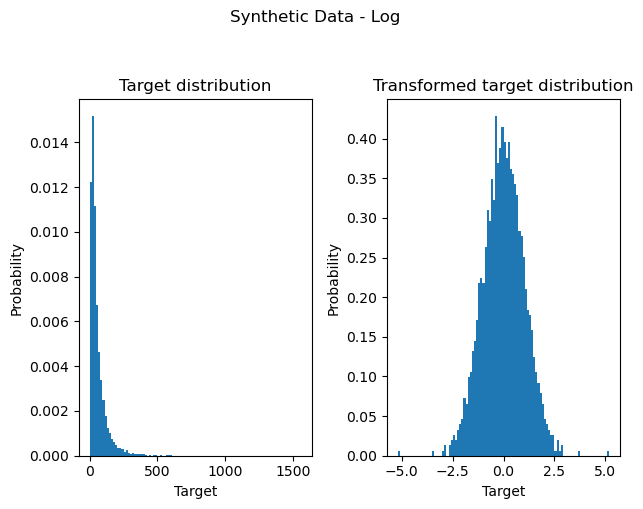

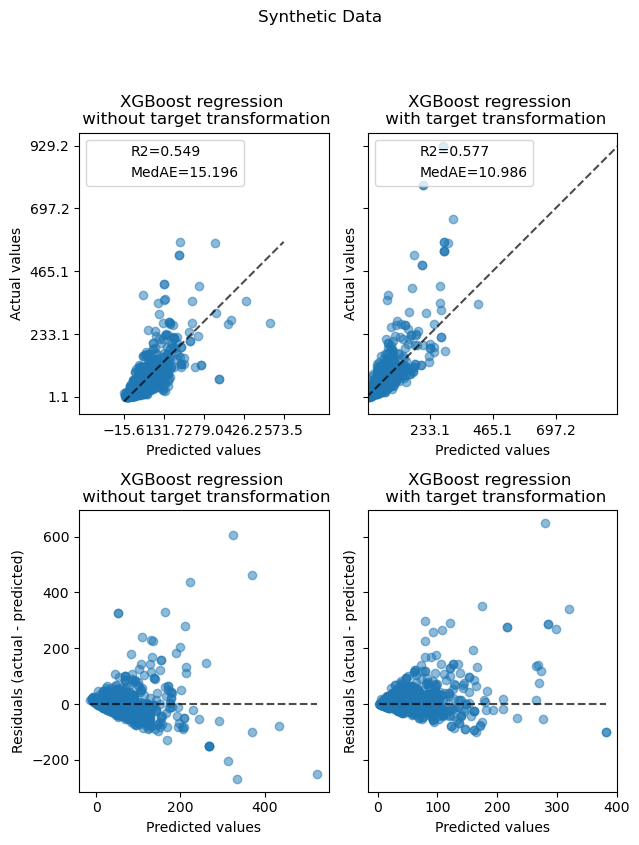

In [46]:
from xgboost import XGBRegressor
from sklearn.preprocessing import QuantileTransformer

# X, y = make_regression(n_samples=10000, n_features=20, n_informative=15, random_state=1)
X, y = make_regression(n_samples=10_000, n_features=20, n_informative=15, noise=100, random_state=0)

f, (ax0, ax1) = plt.subplots(1, 2)

ax0.hist(y, bins=100, density=True)
ax0.set_ylabel("Probability")
ax0.set_xlabel("Target")
ax0.set_title("Target distribution")

ax1.hist(y_trans, bins=100, density=True)
ax1.set_ylabel("Probability")
ax1.set_xlabel("Target")
ax1.set_title("Transformed target distribution")

f.suptitle("Synthetic Data - no log", y=1.05)
plt.tight_layout()

y = np.expm1((y + abs(y.min())) / 250)

f, (ax0, ax1) = plt.subplots(1, 2)

ax0.hist(y, bins=100, density=True)
ax0.set_ylabel("Probability")
ax0.set_xlabel("Target")
ax0.set_title("Target distribution")

ax1.hist(y_trans, bins=100, density=True)
ax1.set_ylabel("Probability")
ax1.set_xlabel("Target")
ax1.set_title("Transformed target distribution")

f.suptitle("Synthetic Data - Log", y=1.05)
plt.tight_layout()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# y_train = le.fit_transform(y_train)
# y_test = le.transform(y_test)

# define the model
model = XGBRegressor()

f, (ax0, ax1) = plt.subplots(2, 2, sharey="row", figsize=(6.5, 8))

xgb_model = model.fit(X_train, y_train)
y_pred_xgb_model = xgb_model.predict(X_test)

xgb_model_with_trans_target = TransformedTargetRegressor(
    regressor=model,
    transformer=QuantileTransformer(n_quantiles=900, output_distribution="normal"),
).fit(X_train, y_train)
y_pred_xgb_model_with_trans_target = xgb_model_with_trans_target.predict(X_test)

# plot the actual vs predicted values
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred_xgb_model,
    kind="actual_vs_predicted",
    ax=ax0[0],
    scatter_kwargs={"alpha": 0.5},
)
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred_xgb_model_with_trans_target,
    kind="actual_vs_predicted",
    ax=ax0[1],
    scatter_kwargs={"alpha": 0.5},
)

# Add the score in the legend of each axis
for ax, y_pred in zip([ax0[0], ax0[1]], [y_pred_xgb_model, y_pred_xgb_model_with_trans_target]):
    for name, score in compute_score(y_test, y_pred).items():
        ax.plot([], [], " ", label=f"{name}={score}")
    ax.legend(loc="upper left")

ax0[0].set_title("XGBoost regression \n without target transformation")
ax0[1].set_title("XGBoost regression \n with target transformation")

# plot the residuals vs the predicted values
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred_xgb_model,
    kind="residual_vs_predicted",
    ax=ax1[0],
    scatter_kwargs={"alpha": 0.5},
)
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred_xgb_model_with_trans_target,
    kind="residual_vs_predicted",
    ax=ax1[1],
    scatter_kwargs={"alpha": 0.5},
)
ax1[0].set_title("XGBoost regression \n without target transformation")
ax1[1].set_title("XGBoost regression \n with target transformation")

f.suptitle("Synthetic Data", y=1.05)
plt.tight_layout()
plt.show()

### KNN

In [60]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_score, recall_score
import seaborn as sns

X, y = make_classification(n_samples=10000, n_features=20, n_informative=15, n_redundant=5, random_state=1, n_classes=3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# print(compute_score(y_test, y_pred))

Accuracy: 0.9135


In [53]:
k_values = [i for i in range (1,31)]
scores = []

scaler = StandardScaler()
X = scaler.fit_transform(X)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X, y, cv=5)
    scores.append(np.mean(score))

Text(0, 0.5, 'Accuracy Score')

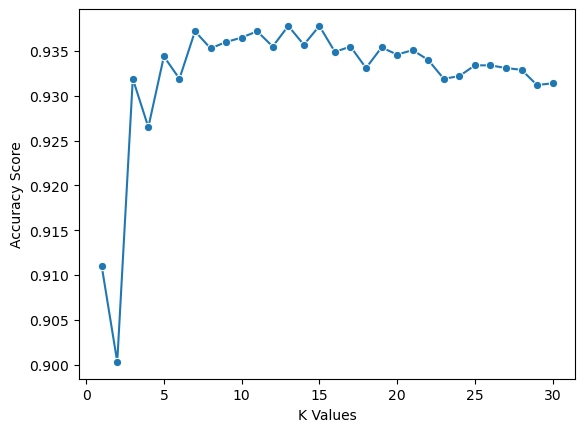

In [56]:
sns.lineplot(x = k_values, y = scores, marker = 'o')
plt.xlabel("K Values")
plt.ylabel("Accuracy Score")

In [61]:
best_index = np.argmax(scores)
best_k = k_values[best_index]

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=13)

In [65]:
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.9235
Precision: 0.9248024023857936
Recall: 0.9235


### Gaussian Mixture Modelling (GMM)

In [ ]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2, random_state=42)

gmm.fit(train_df.target.values.reshape(-1, 1))

train_df['target_class'] = gmm.predict(train_df.target.values.reshape(-1, 1))

In [ ]:
f, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
sns.kdeplot(data=train_df.target, ax=ax[0])
ax[0].set_title('Before GMM', fontsize=16)
sns.kdeplot(data=train_df[train_df.target_class==0].target, label='Component 1', ax=ax[1])
sns.kdeplot(data=train_df[train_df.target_class==1].target, label='Component 2', ax=ax[1])
ax[1].set_title('After GMM', fontsize=16)
plt.show()

### Imports

In [2]:
#%% Imports
import numpy as np
import pandas as pd
import random
import seaborn as sns
import time
from datetime import datetime, timedelta, date
import matplotlib.pyplot as plt
# import chdb -- needs Linux / OSX
# from chdb.session import Session
# import chdb.dataframe as cdf
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, PowerTransformer, KBinsDiscretizer, QuantileTransformer, quantile_transform
from sklearn.model_selection import GridSearchCV, train_test_split, TimeSeriesSplit, cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, RocCurveDisplay, roc_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, roc_auc_score, root_mean_squared_error,r2_score, PredictionErrorDisplay, mean_absolute_error, median_absolute_error
from sklearn.compose import TransformedTargetRegressor, ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from xgboost import XGBClassifier, XGBRegressor
import joblib

pd.options.mode.copy_on_write = True
random.seed(10765)
baseDataPath = '../oanda_downloader/data/'

### Load Data

In [3]:
#%% Load Data
def load_df_from_parquet(parquetFile):
    #Load optimised dataframe from parquet file
    start = time.time()
    dfFile = parquetFile
    df = pd.read_parquet(path=dfFile)
    end = time.time()
    print(f"Loaded Parquet Data:{parquetFile}, took:{end - start}")
    return df

def loadDataSet(instrument, tf):          
    dfFile = f"{baseDataPath}oanda_features_{instrument}_{tf}.parquet"
    return load_df_from_parquet(dfFile)

instrument = 'NAS100_USD' #'EUR_USD'
days = []
bins = [0, 1, 2, 3, 4, 5, 6, 7]
day_names = np.array(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

## Weekly:
df_weekly = loadDataSet(instrument, 'W1')
df_weekly['high_day_of_week_trading'] = day_names[df_weekly['high_day_of_week_trading']]
df_weekly['high_day_of_week_trading'] = pd.Categorical(df_weekly['high_day_of_week_trading'], categories=day_names)
df_weekly['low_day_of_week_trading'] = day_names[df_weekly['low_day_of_week_trading']]
df_weekly['low_day_of_week_trading'] = pd.Categorical(df_weekly['low_day_of_week_trading'], categories=day_names)


## Daily:
df_daily = loadDataSet(instrument, 'D1')
df_daily = df_daily.rename(columns={"high_proportion_of_day": "high_proportion_of_interval", "low_proportion_of_day": "low_proportion_of_interval"}) 

## 4 Hourly:
df_4hourly = loadDataSet(instrument, 'H4')

## Hourly:
df_hourly = loadDataSet(instrument, 'H1')

## M15:
df_m15 = loadDataSet(instrument, 'M15')

## M5:
df_m5 = loadDataSet(instrument, 'M5')

## M1:
df_m1 = loadDataSet(instrument, 'M1')

Loaded Parquet Data:../oanda_downloader/data/oanda_features_NAS100_USD_W1.parquet, took:0.1449875831604004
Loaded Parquet Data:../oanda_downloader/data/oanda_features_NAS100_USD_D1.parquet, took:0.011876821517944336
Loaded Parquet Data:../oanda_downloader/data/oanda_features_NAS100_USD_H4.parquet, took:0.018857240676879883
Loaded Parquet Data:../oanda_downloader/data/oanda_features_NAS100_USD_H1.parquet, took:0.04061722755432129
Loaded Parquet Data:../oanda_downloader/data/oanda_features_NAS100_USD_M15.parquet, took:0.12000894546508789
Loaded Parquet Data:../oanda_downloader/data/oanda_features_NAS100_USD_M5.parquet, took:0.27492809295654297
Loaded Parquet Data:../oanda_downloader/data/oanda_features_NAS100_USD_M1.parquet, took:1.2894952297210693


### Func

In [4]:
#%% Functions
def add_features_to_df(df_base):
    # Add some Features:
    df_base['oh_range'] = df_base['high'] - df_base['open']
    df_base['ol_range'] = df_base['open'] - df_base['low']
    df_base['ch_range'] = df_base['high'] - df_base['close']
    df_base['cl_range'] = df_base['close'] - df_base['low']

    df_base['interval_range_return_ratio'] = df_base['interval_return'] / df_base['interval_range']

    df_base['oh_ol_ratio'] = df_base['oh_range'] / df_base['ol_range']
    df_base['oh_ch_ratio'] = df_base['oh_range'] / df_base['ch_range']
    df_base['oh_cl_ratio'] = df_base['oh_range'] / df_base['cl_range']
    df_base['ol_ch_ratio'] = df_base['ol_range'] / df_base['ch_range']
    df_base['ol_cl_ratio'] = df_base['ol_range'] / df_base['cl_range']
    df_base['ch_cl_ratio'] = df_base['ch_range'] / df_base['cl_range']

    df_base['oh_interval_range_ratio'] = df_base['oh_range'] / df_base['interval_range']
    df_base['oh_interval_return_ratio'] = df_base['oh_range'] / df_base['interval_return']
    df_base['oh_ATR_ratio'] = df_base['oh_range'] / df_base['ATR']

    df_base['ol_interval_range_ratio'] = df_base['ol_range'] / df_base['interval_range']
    df_base['ol_interval_return_ratio'] = df_base['ol_range'] / df_base['interval_return']
    df_base['ol_ATR_ratio'] = df_base['ol_range'] / df_base['ATR']

    df_base['ch_interval_range_ratio'] = df_base['ch_range'] / df_base['interval_range']
    df_base['ch_interval_return_ratio'] = df_base['ch_range'] / df_base['interval_return']
    df_base['ch_ATR_ratio'] = df_base['ch_range'] / df_base['ATR']

    df_base['cl_interval_range_ratio'] = df_base['cl_range'] / df_base['interval_range']
    df_base['cl_interval_return_ratio'] = df_base['cl_range'] / df_base['interval_return']
    df_base['cl_ATR_ratio'] = df_base['cl_range'] / df_base['ATR']
    
    return df_base

def add_shifted_column(df, c, i):
    dfnew = pd.DataFrame()
    dfnew[c + str(i)] = df[c].shift(-i)
    return dfnew

def create_shifted_columns(df, columns, shift_count, drop_na=False):
    
    x=shift_count +1
    new_columns = []
    
    for i in range(1,x):
        new_df_tmp = pd.concat([add_shifted_column(df, c, i) for c in columns], axis=1)
        df = pd.concat([df,  new_df_tmp], axis=1)
        new_columns = new_columns + [c +str(i) for c in columns]
    if drop_na: 
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        df = df.dropna()
    new_df = df.copy()
    
    return new_df, new_columns

def getTrainTestData(df, feature_cols, target_col, holdback_proportion):
    X = df[feature_cols]
    Y = pd.Series(df[target_col])
    # Y_class = pd.Series(df[target_col_class])

    # X contains features, y contains target labels
    # X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42) - Only use if no prior info engineered into features last period x ADR etc

    #Split off last 20% of Data for OOS Testing of Model.
    test_size = int(X.shape[0] - (X.shape[0] * holdback_proportion))
    x_test = X.iloc[test_size:]
    x_train = X.iloc[:test_size]
    y_test = Y.iloc[test_size:]
    y_train = Y.iloc[:test_size]
    
    return x_test, x_train, y_test, y_train

def getFeatureEngineeredTestTrainData(source_df, descriptive_cols, end_of_period_num_cols, end_of_period_cat_cols, target_col, intervals_lookback):
    # intervals_lookback = 5
    holdback_proportion = 0.2
    
    source_df = add_features_to_df(source_df)
    
    df_ml = source_df[descriptive_cols + end_of_period_num_cols + end_of_period_cat_cols] 

    df_ml, new_num_features = create_shifted_columns(df_ml, end_of_period_num_cols, intervals_lookback)
    numeric_features = new_num_features

    df_ml, new_cat_features = create_shifted_columns(df_ml, end_of_period_cat_cols, intervals_lookback, drop_na=True)
    categorical_features = descriptive_cols + new_cat_features

    feature_cols = categorical_features + numeric_features

    x_test, x_train, y_test, y_train = getTrainTestData(df_ml, feature_cols, target_col, holdback_proportion)
    
    return x_test, x_train, y_test, y_train, categorical_features, numeric_features

def create_RF_CLF_GridSearch(intervals_lookback, preprocessorRF=None, param_grid=None):
    tscv = TimeSeriesSplit(n_splits=5, gap=intervals_lookback+1)
    clf = RandomForestClassifier(random_state=0) #, class_weight='balanced_subsample')
    if preprocessorRF is None:
        preprocessorRF = ColumnTransformer(
            transformers=[
            # ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan), categorical_features),
            # ('num', Pipeline([
            #             ("standardScaler",  StandardScaler()), #PowerTransformer()),
            #             # ("quantiles", QuantileTransformer(n_quantiles=50, output_distribution="normal")),
            #             # ("Kbins", KBinsDiscretizer(n_bins=20, encode="ordinal") )
            #     ]), numeric_features),#StandardScaler(), numeric_features)
            ],
            remainder='passthrough'  # This keeps the remaining columns (numeric) as they are
        )

    # Create the full pipeline
    pipelineRF = Pipeline(steps=[
        ('preprocessor', preprocessorRF),  # Apply the preprocessor
        ('classifier', clf)        # Apply the RF model
    ])

    # Define hyperparameters to tune during cross-validation
    if param_grid is None:
        param_grid = {
        'classifier__n_estimators': [300],  # Number of trees
        'classifier__max_depth': [20, 50, 60],  # Maximum depth of trees
        'classifier__max_features': ['log2', 'sqrt', 10, 100],
        'classifier__min_samples_leaf': [1, 4],
        'classifier__min_samples_split': [2, 10],
        }
        
    grid_search = GridSearchCV(pipelineRF, param_grid, cv=tscv, scoring='f1', verbose=2, n_jobs=-2) # roc_auc,n_jobs=-4 'neg_mean_absolute_error' roc_auc_ovo_weighted f1
    return grid_search

def runRFGridSearch(grid_search, x_train, y_train, x_test, y_test, feature_cols, label=None):
    if label is None:
        d = date.today()
        label = d.strftime("%y_%d_%m")
        
    # Fit the model using grid search with cross-validation
    grid_search.fit(x_train, y_train)
    
    # Find the best parameters from cross-validation
    print(f"Best Parameters: {grid_search.best_params_}")
    print(f"Best Score: {grid_search.best_score_}")
        
    # Predict and evaluate the model on the test set using the best model
    clf = grid_search.best_estimator_['classifier']

    filename = f'rf_model_{label}.sav'
    joblib.dump(clf, filename)
    
    # load the model from disk
    clf = joblib.load(filename)

    y_pred = clf.predict(x_test.values)
    y_pred_proba = clf.predict_proba(x_test.values)

    y_true = y_test

    scores = {
            "ROC 0": f"{roc_auc_score(y_true, y_pred_proba[:,0], multi_class='ovr'):.3f}",
            "ROC 1": f"{roc_auc_score(y_true, y_pred_proba[:,1], multi_class='ovr'):.3f}",
            "Accuracy": f"{accuracy_score(y_true, y_pred):.3f}",
            "Precision": f"{precision_score(y_true, y_pred, average='weighted', zero_division=np.nan):.3f}",
            "Recall": f"{recall_score(y_test, y_pred, average='weighted'):.3f}"
        }

    print(scores)
    
    cm = confusion_matrix(y_test, y_pred, normalize='all')
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred) #, normalize='all')
    fig, ax = plt.subplots (figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='.2f', linewidths=.3)
    plt.show ()


    plt.figure(figsize=(40,40))
    plt.subplots(1, 1, figsize=(15, 25))
    importances = clf.feature_importances_
    df3=pd.DataFrame({'allvarlist':feature_cols,'importances':importances})
    df3.sort_values('importances',inplace=True)
    df3t = df3.iloc[df3.shape[0] - 40:]
    plt.barh(df3t.allvarlist,df3t.importances)
    plt.show()

    g = sns.displot(kind='hist', x=y_true, height=3, bins=100)
    g = sns.displot(kind='hist', x=y_pred, height=3, bins=100)
    # RocCurveDisplay.from_predictions( y_test, y_pred)

    # roc Curve plot
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba[:,0])
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.figure(figsize=(10, 8), dpi = 600)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{label} Nas100USD Direction –– ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

     # roc Curve plot
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba[:,1])
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.figure(figsize=(10, 8), dpi = 600)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{label} Nas100USD Direction –– ROC Curve')
    plt.legend(loc="lower right")
    plt.show()
    
    
    return clf

### Run this...

In [6]:
#%% Feature Column Lists
descriptive_cols = [
    'quarter_of_year', 
    'month_of_year', 
    'week_of_year', 
    'week_of_month',
    'day_of_year', 
    'day_of_month', 
    'day_of_week',
    'hour_of_day',
    'minute_of_hour', 
    'minute_of_day', 
    'second_of_minute']

# Targets
end_of_period_num_cols = [
    'interval_range',
    'interval_return',
    'ATR',
    'high_proportion_of_interval', 
    'low_proportion_of_interval',
    'oh_range',
    'ol_range',
    'ch_range',
    'cl_range',
    'interval_range_return_ratio',
    'oh_ol_ratio',
    'oh_ch_ratio',
    'oh_cl_ratio',
    'ol_ch_ratio',
    'ol_cl_ratio',
    'ch_cl_ratio',
    'oh_interval_range_ratio',
    'oh_interval_return_ratio',
    'oh_ATR_ratio',
    'ol_interval_range_ratio',
    'ol_interval_return_ratio',
    'ol_ATR_ratio',
    'ch_interval_range_ratio',
    'ch_interval_return_ratio',
    'ch_ATR_ratio',
    'cl_interval_range_ratio',
    'cl_interval_return_ratio',
    'cl_ATR_ratio'
    ]

end_of_period_cat_cols = [
    'bullish',
    'high_year',
    'high_quarter_of_year', 
    'high_month_of_year', 
    'high_week_of_year',
    'high_week_of_month', 
    'high_day_of_year', 
    'high_day_of_month',
    'high_day_of_week_trading', 
    'high_hour_of_day',
    'high_hour_of_week_trading', 
    'high_minute_of_hour',
    'high_minute_of_day', 
    'high_second_of_minute', 
    'low_quarter_of_year',
    'low_month_of_year', 
    'low_week_of_year', 
    'low_week_of_month',
    'low_day_of_year', 
    'low_day_of_month', 
    'low_day_of_week_trading',
    'low_hour_of_day',
    'low_hour_of_week_trading', 
    'low_minute_of_hour',
    'low_minute_of_day', 
    'low_second_of_minute']
######

(359, 281) (1432, 281) (359,) (1432,)
Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END classifier__max_depth=20, classifier__max_features=log2, classifier__min_samples_leaf=1, classifier__min_samples_split=10, classifier__n_estimators=300; total time=   2.0s
[CV] END classifier__max_depth=20, classifier__max_features=log2, classifier__min_samples_leaf=4, classifier__min_samples_split=2, classifier__n_estimators=300; total time=   2.3s
[CV] END classifier__max_depth=20, classifier__max_features=sqrt, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=300; total time=   1.3s
[CV] END classifier__max_depth=20, classifier__max_features=sqrt, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=500; total time=   2.1s
[CV] END classifier__max_depth=20, classifier__max_features=sqrt, classifier__min_samples_leaf=4, classifier__min_samples_split=2, classifier__n_estimators=300; total time=   1.6s

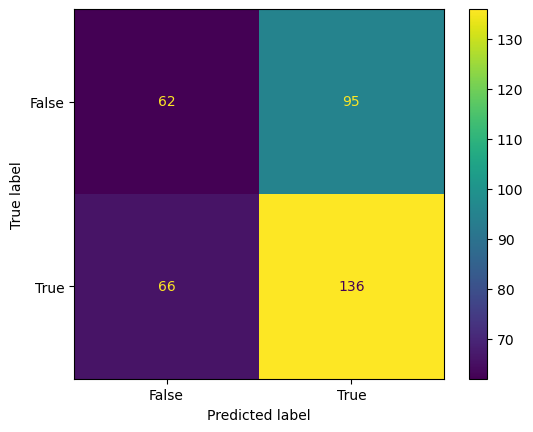

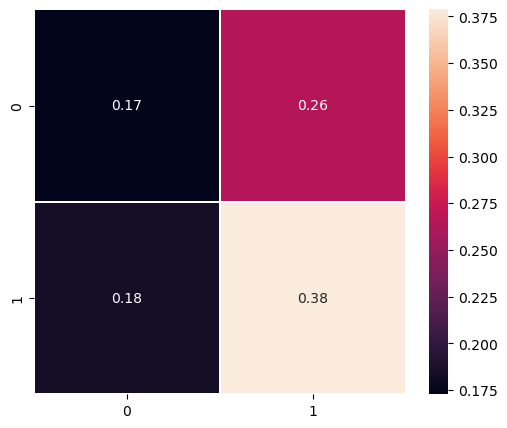

<Figure size 4000x4000 with 0 Axes>

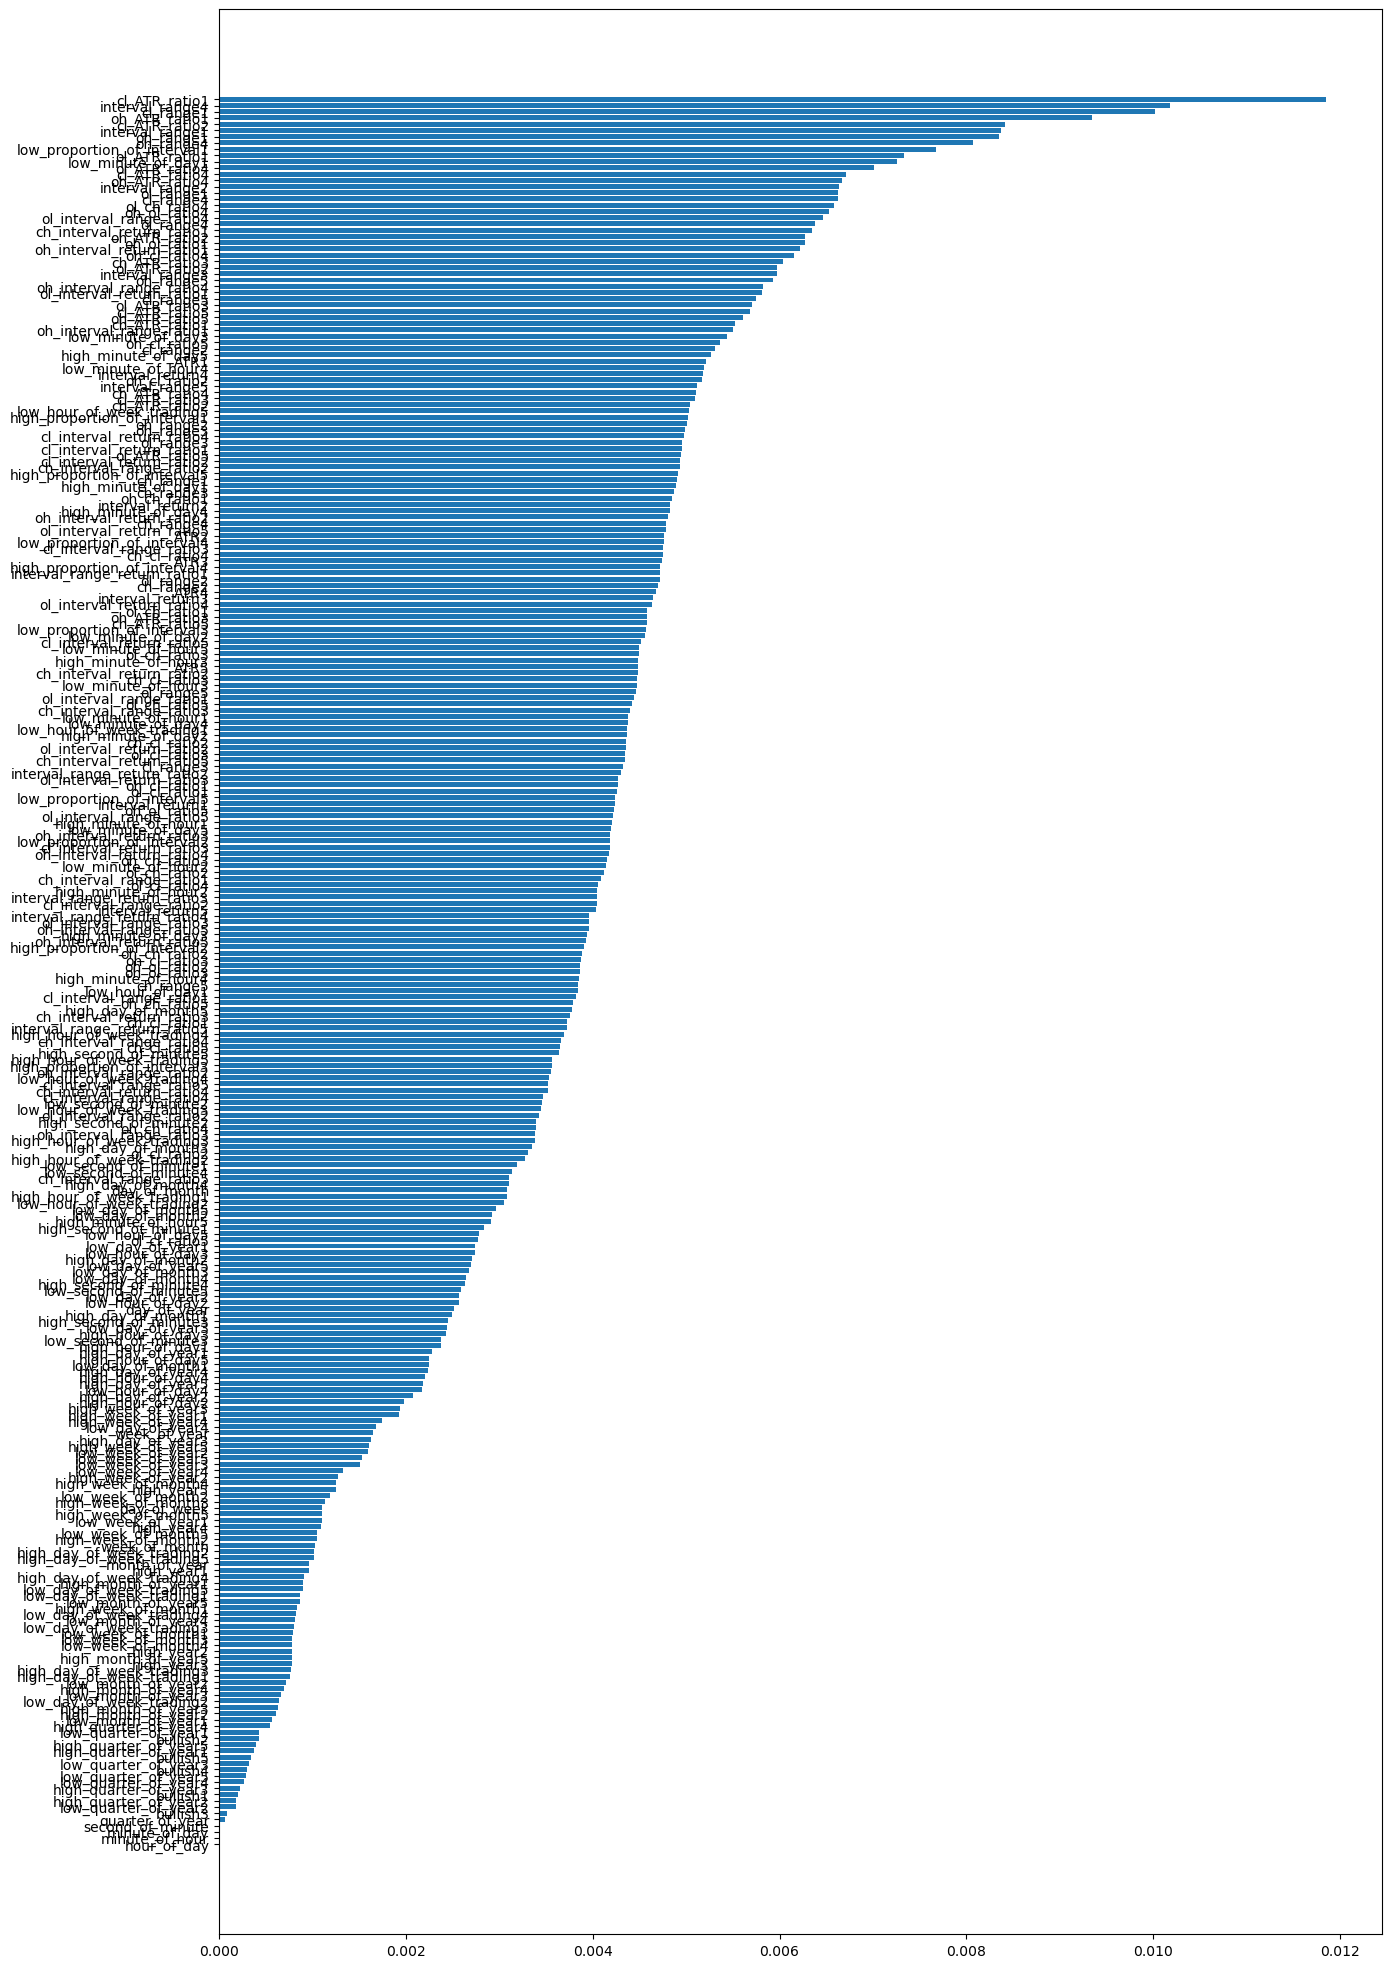

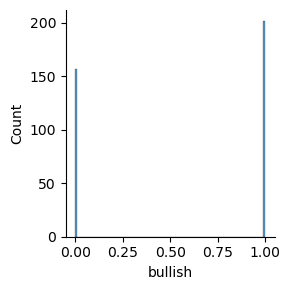

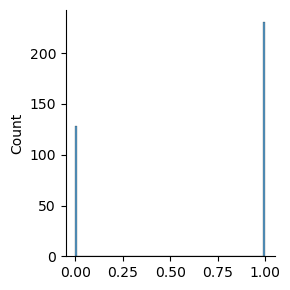

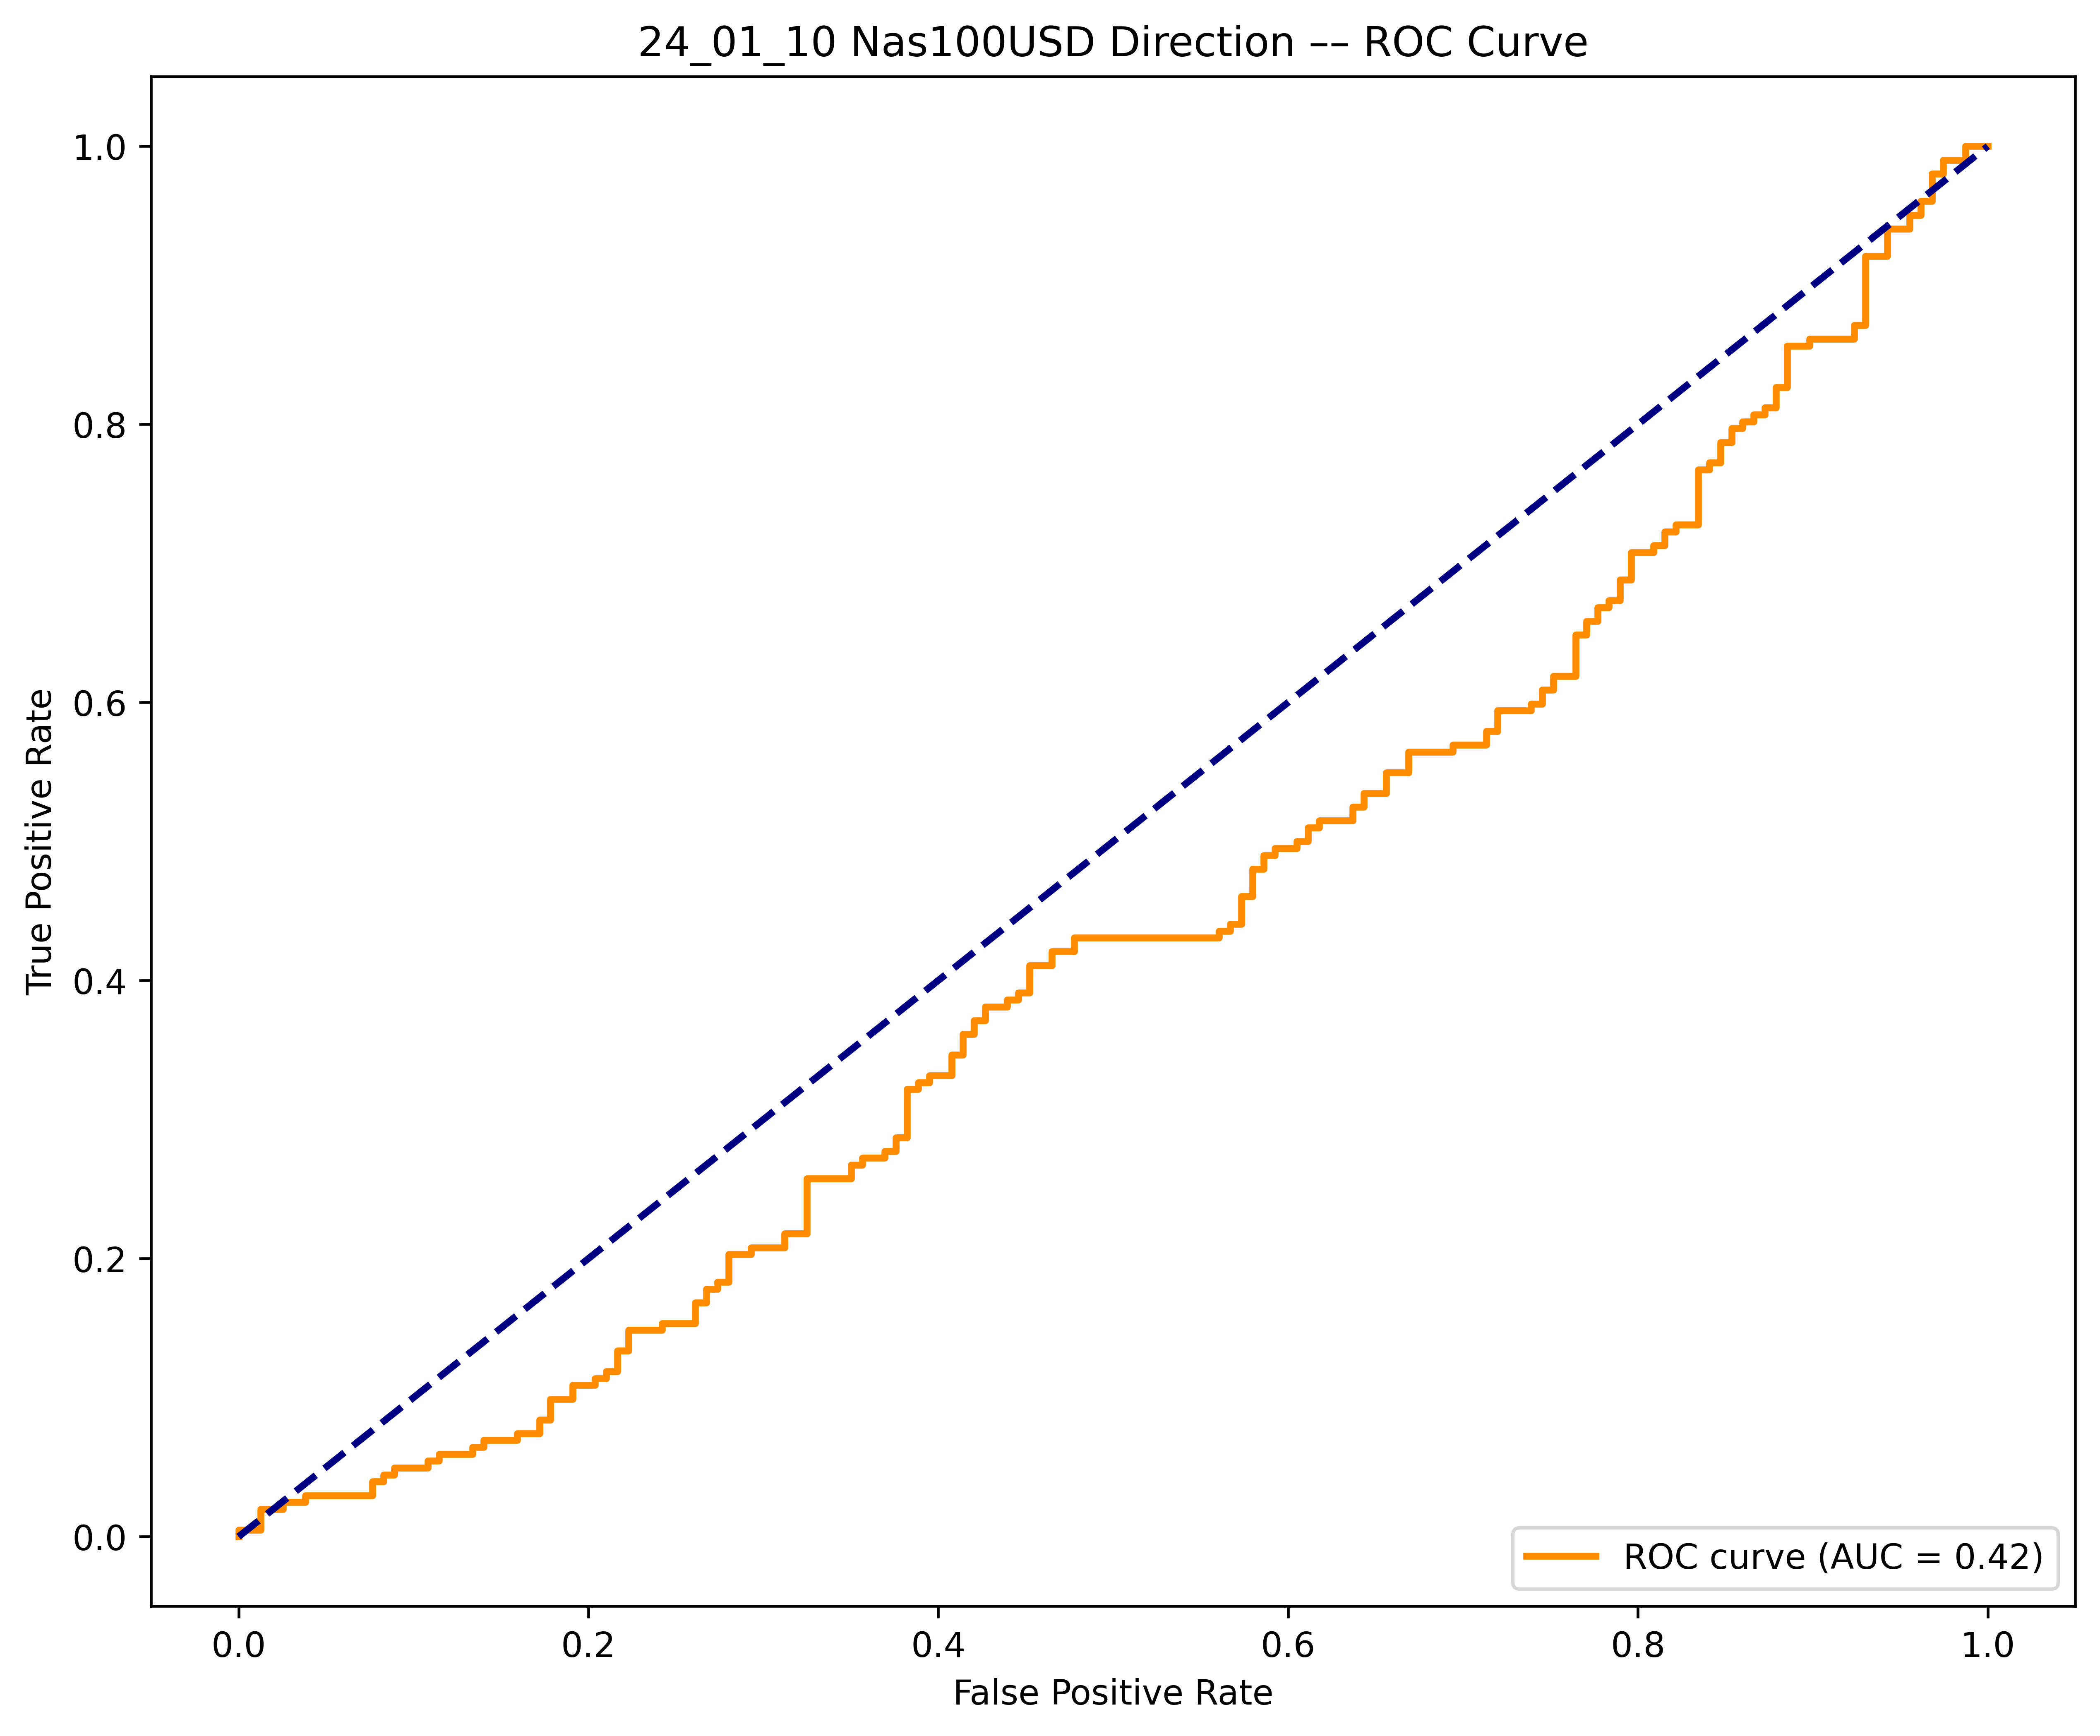

In [99]:
#%% Random Forest - Multi Output Classification
intervals_lookback = 5
target_col = 'bullish' #'high_hour_of_day'#'interval_return' #'high_proportion_of_day'#'high_hour_of_day' #'bullish' #'high_hour_of_day' # Colud be any of the End of Periood Columns

x_test, x_train, y_test, y_train, categorical_features, numeric_features = getFeatureEngineeredTestTrainData(df_daily, descriptive_cols, end_of_period_num_cols, end_of_period_cat_cols, target_col, intervals_lookback)

preprocessorRF = ColumnTransformer(
    transformers=[
        # ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan), categorical_features),
        # ('num', Pipeline([
        #             ("standardScaler",  StandardScaler()), #PowerTransformer()),
        #             # ("quantiles", QuantileTransformer(n_quantiles=50, output_distribution="normal")),
        #             # ("Kbins", KBinsDiscretizer(n_bins=20, encode="ordinal") )
        #     ]), numeric_features),#StandardScaler(), numeric_features)
    ],
    remainder='passthrough'  # This keeps the remaining columns (numeric) as they are
)

# Define hyperparameters to tune during cross-validation
param_grid = {
    'classifier__n_estimators': [300, 500],  # Number of trees
    # 'classifier__learning_rate': [0.0077, 0.008, 0.0082],  # Learning rate
    'classifier__max_depth': [20, 50],  # Maximum depth of trees
    'classifier__max_features': ['log2', 'sqrt', 10],
    'classifier__min_samples_leaf': [1, 4],
    'classifier__min_samples_split': [2, 10],
    # 'classifier__min_child_weight':range(1,6,2)
}

feature_cols = categorical_features + numeric_features

grid_search = create_RF_CLF_GridSearch(intervals_lookback, preprocessorRF, param_grid)    
    
clf = runRFGridSearch(grid_search, x_train, y_train, x_test, y_test, feature_cols)    

### H1 RF Bullish:

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END classifier__max_depth=4, classifier__n_estimators=2000; total time=  57.8s
[CV] END classifier__max_depth=4, classifier__n_estimators=4000; total time= 3.3min
[CV] END classifier__max_depth=3, classifier__n_estimators=2000; total time= 2.4min
[CV] END classifier__max_depth=5, classifier__n_estimators=2000; total time= 2.1min
[CV] END classifier__max_depth=3, classifier__n_estimators=4000; total time= 5.1min
[CV] END classifier__max_depth=3, classifier__n_estimators=2000; total time= 2.0min
[CV] END classifier__max_depth=5, classifier__n_estimators=2000; total time= 1.1min
[CV] END classifier__max_depth=5, classifier__n_estimators=4000; total time= 2.1min
[CV] END classifier__max_depth=3, classifier__n_estimators=2000; total time=  42.1s
[CV] END classifier__max_depth=4, classifier__n_estimators=4000; total time= 1.7min
[CV] END classifier__max_depth=5, classifier__n_estimators=2000; total time= 3.0min
[CV] END classif

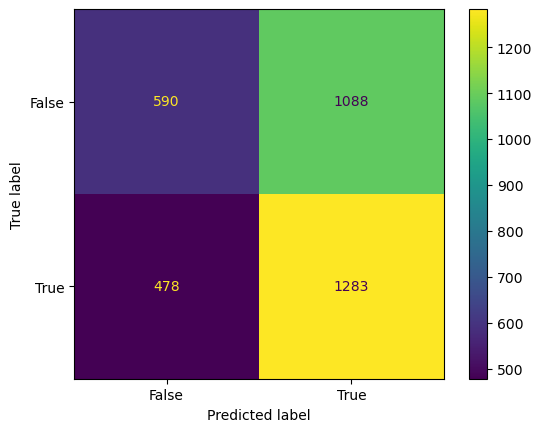

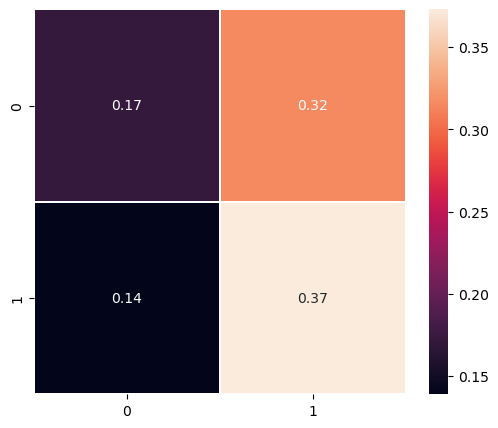

<Figure size 4000x4000 with 0 Axes>

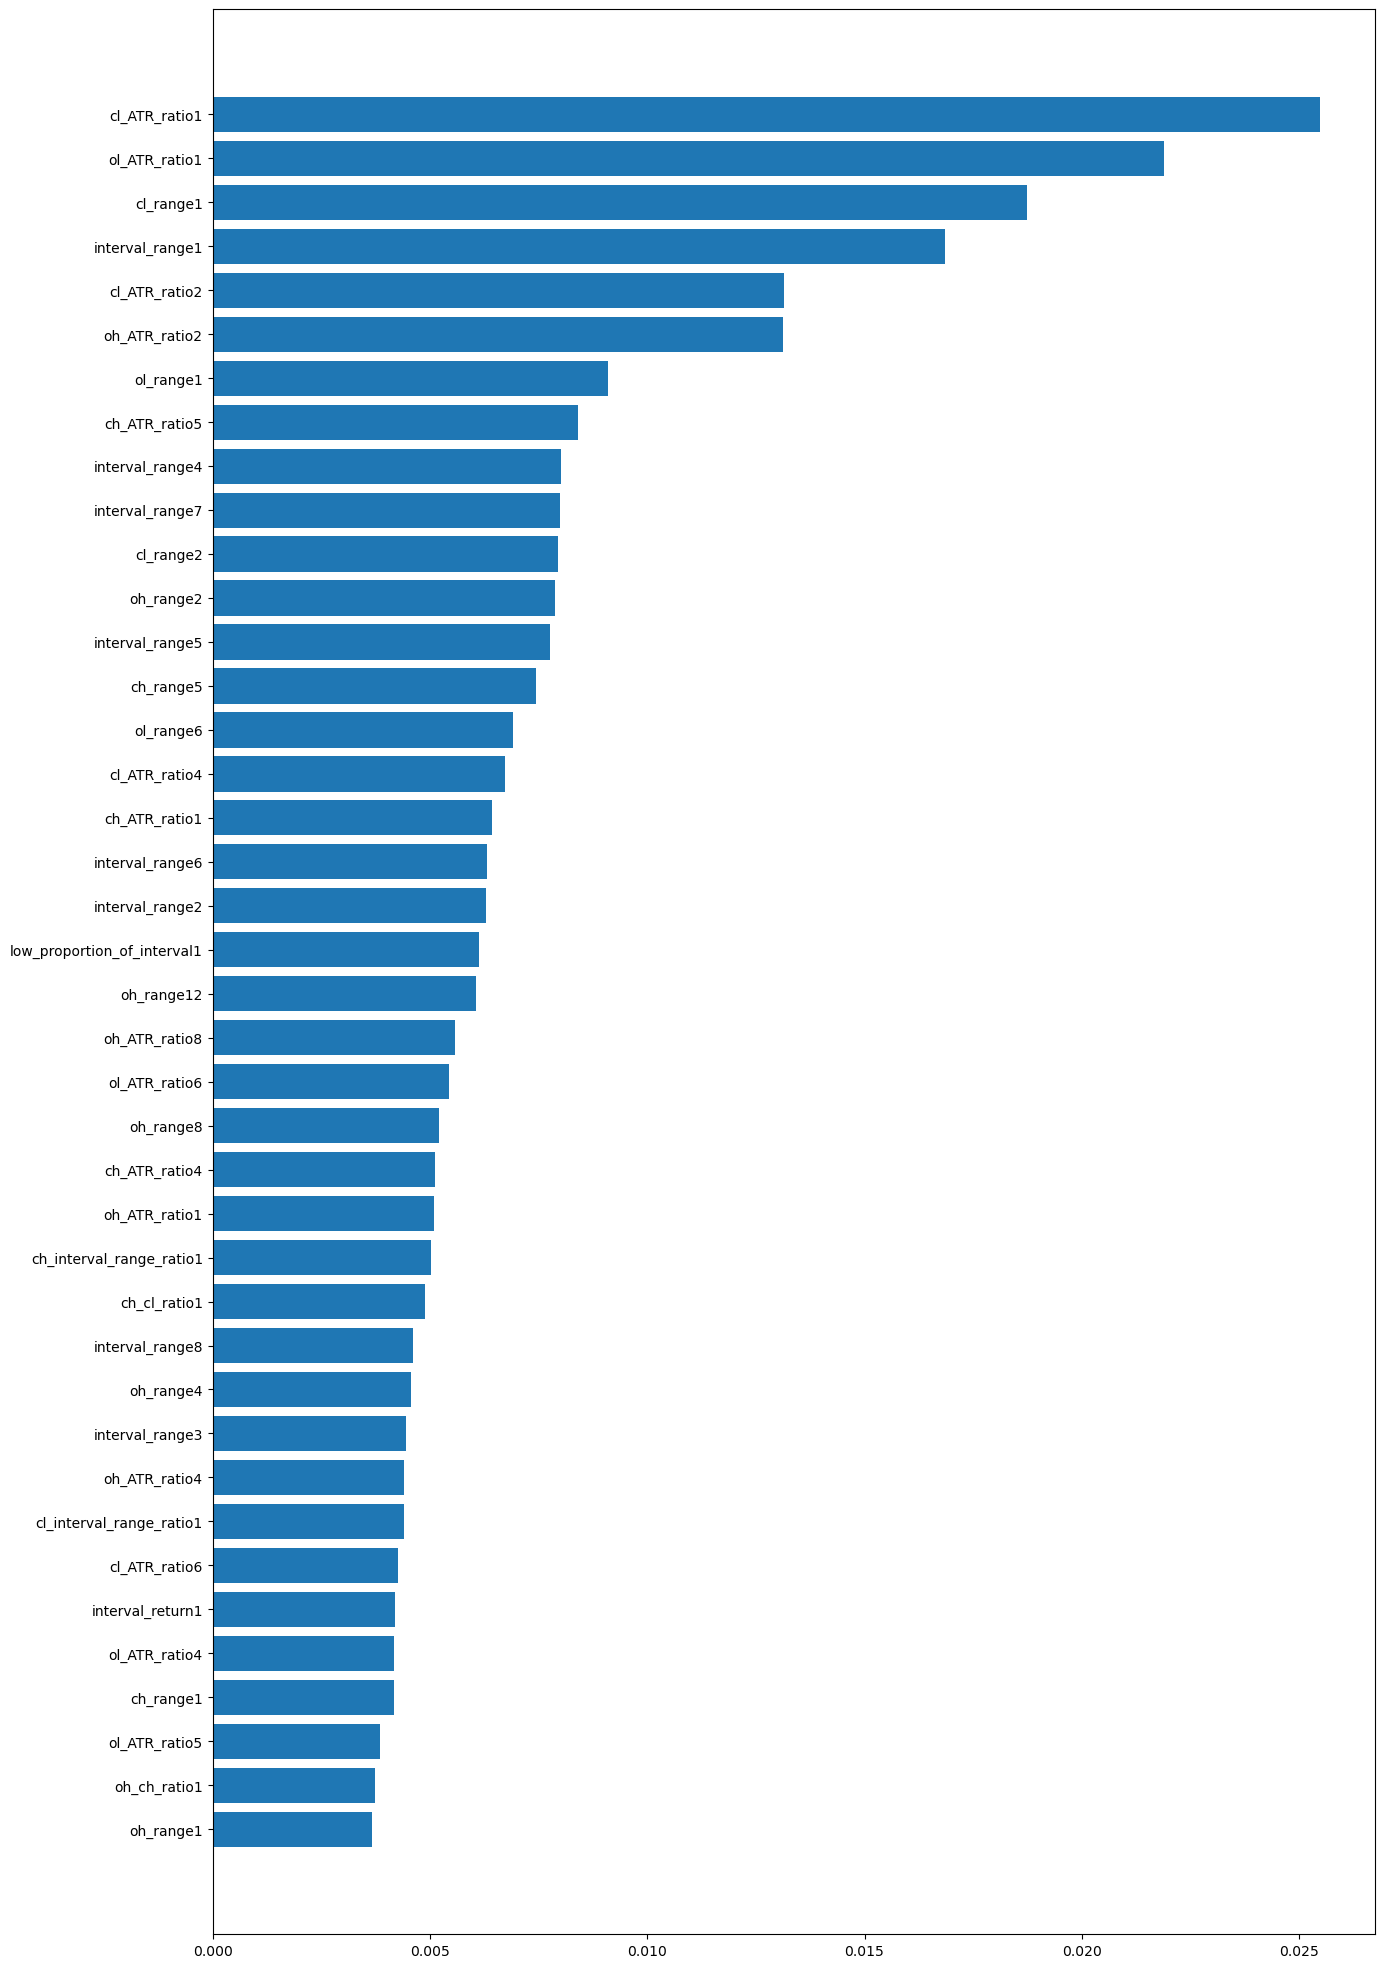

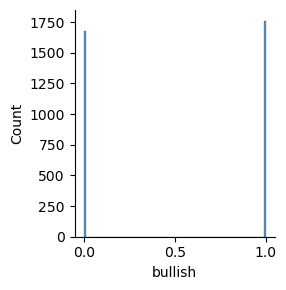

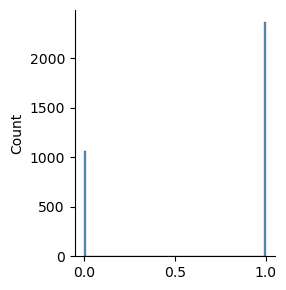

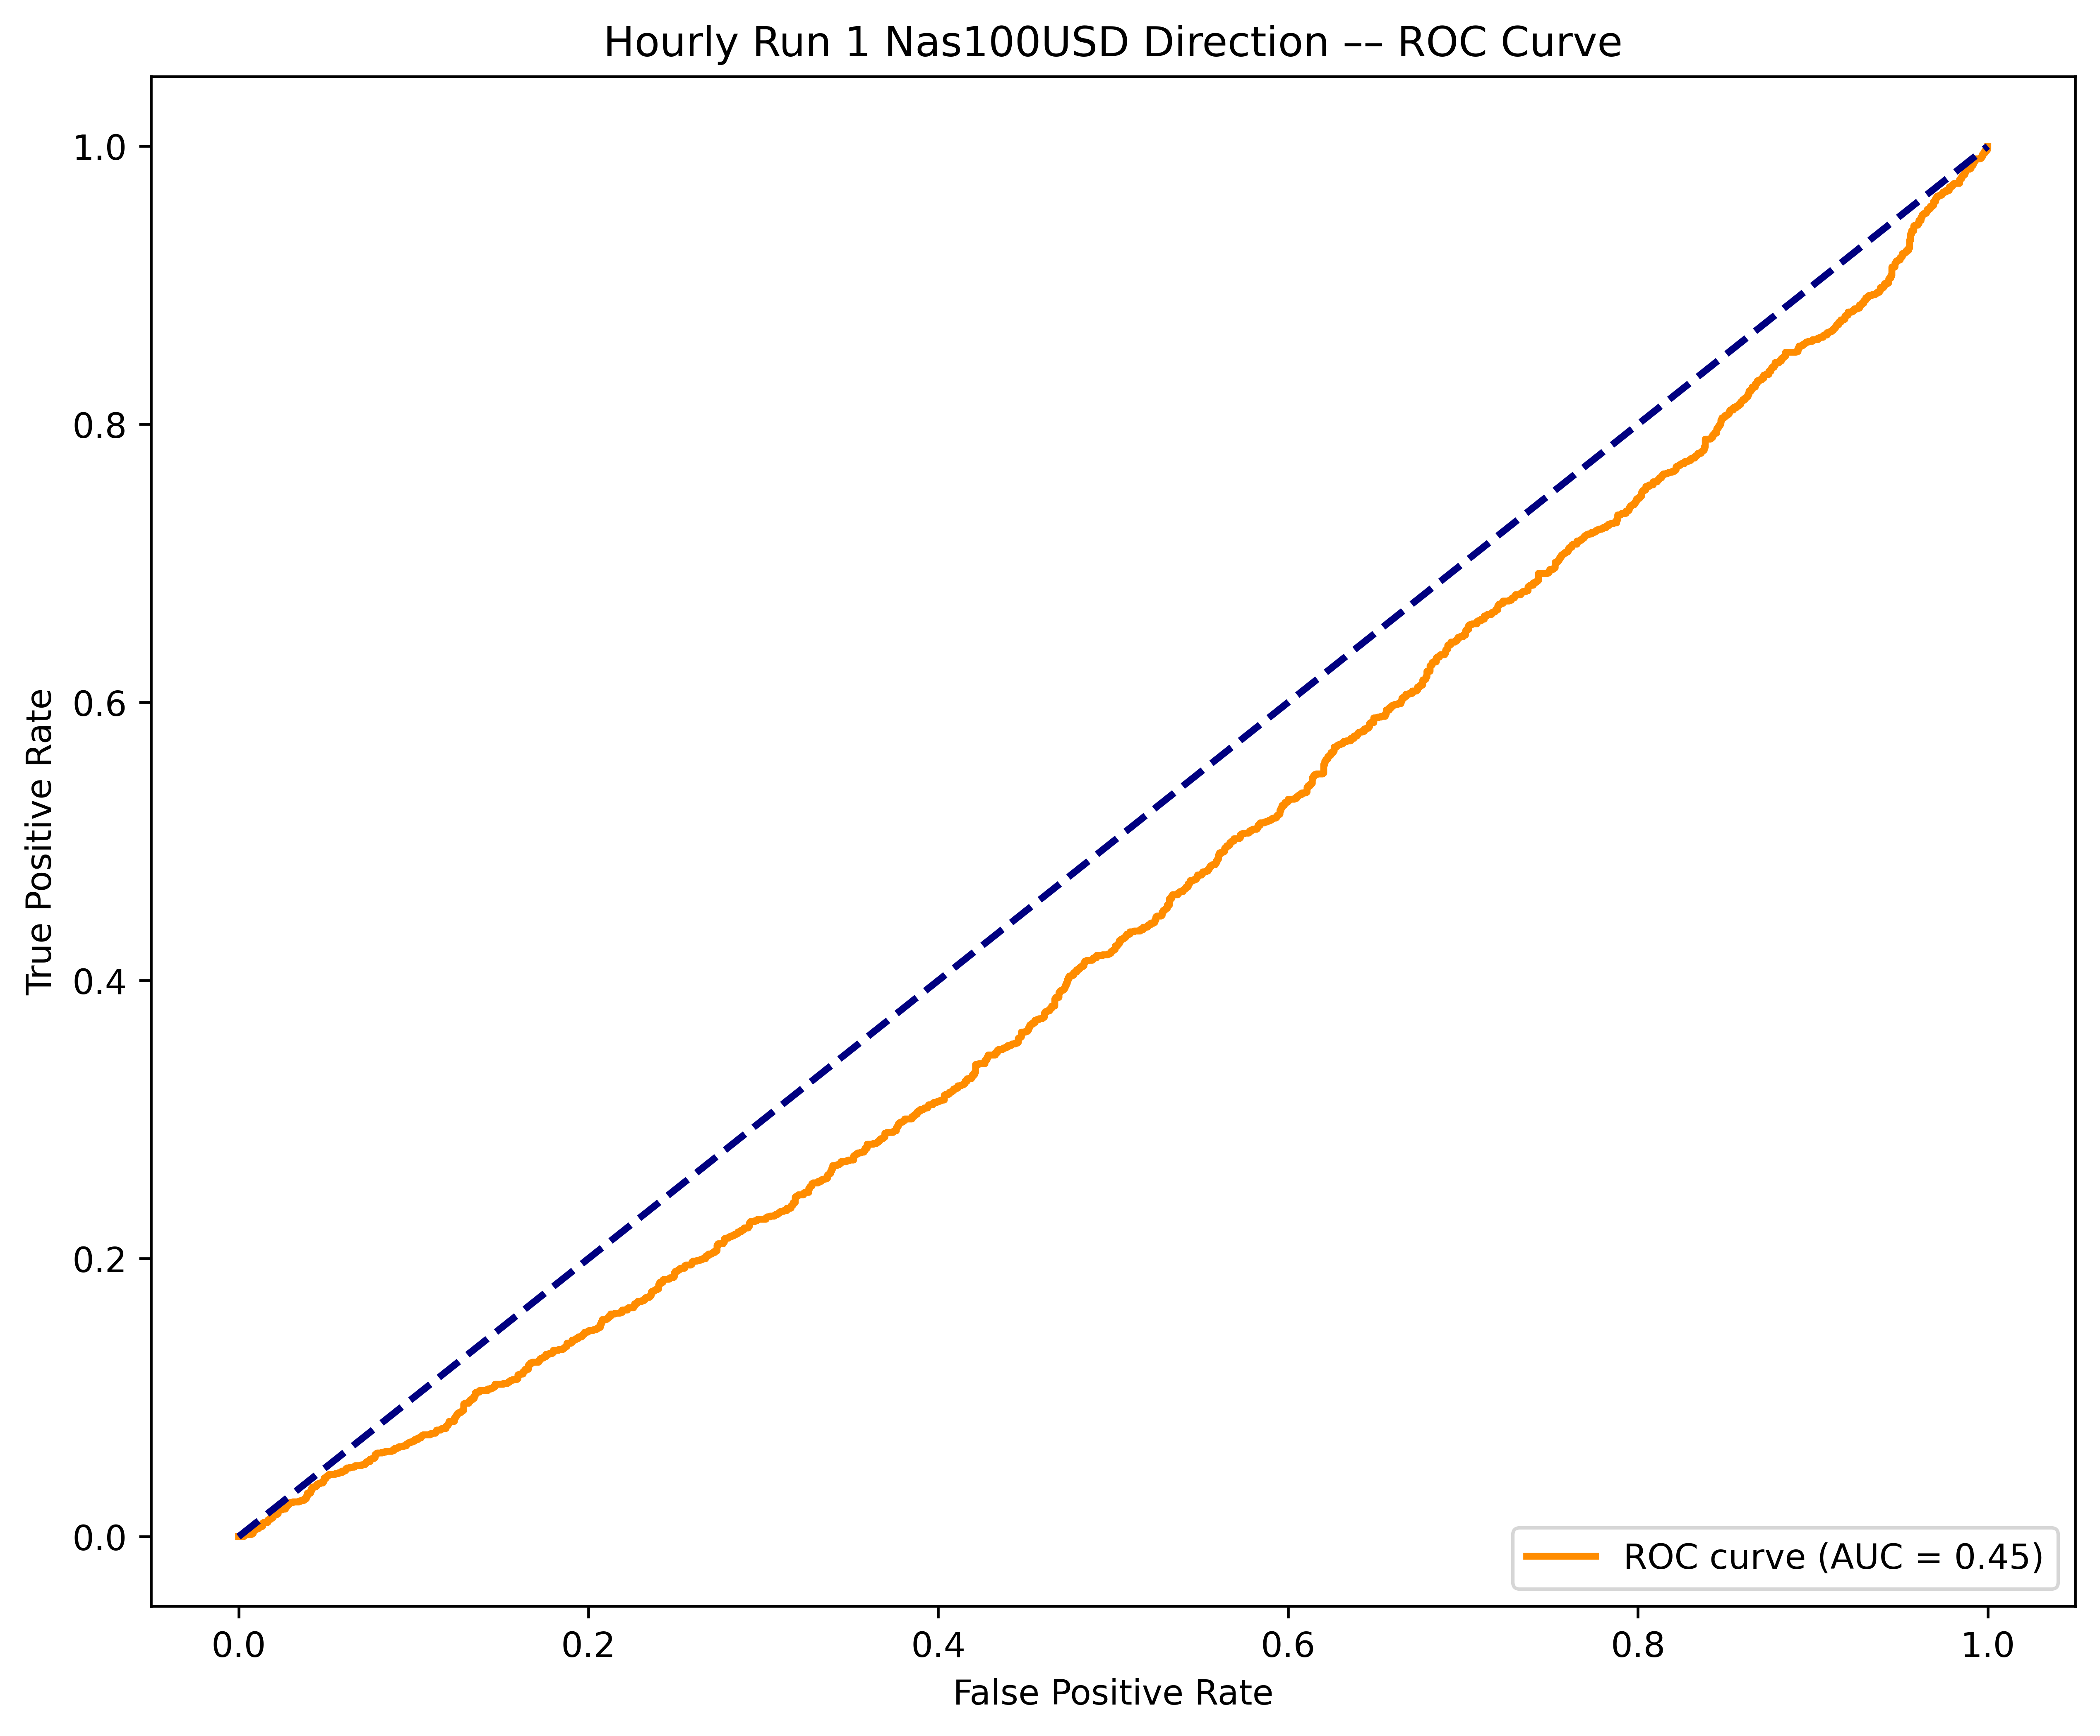

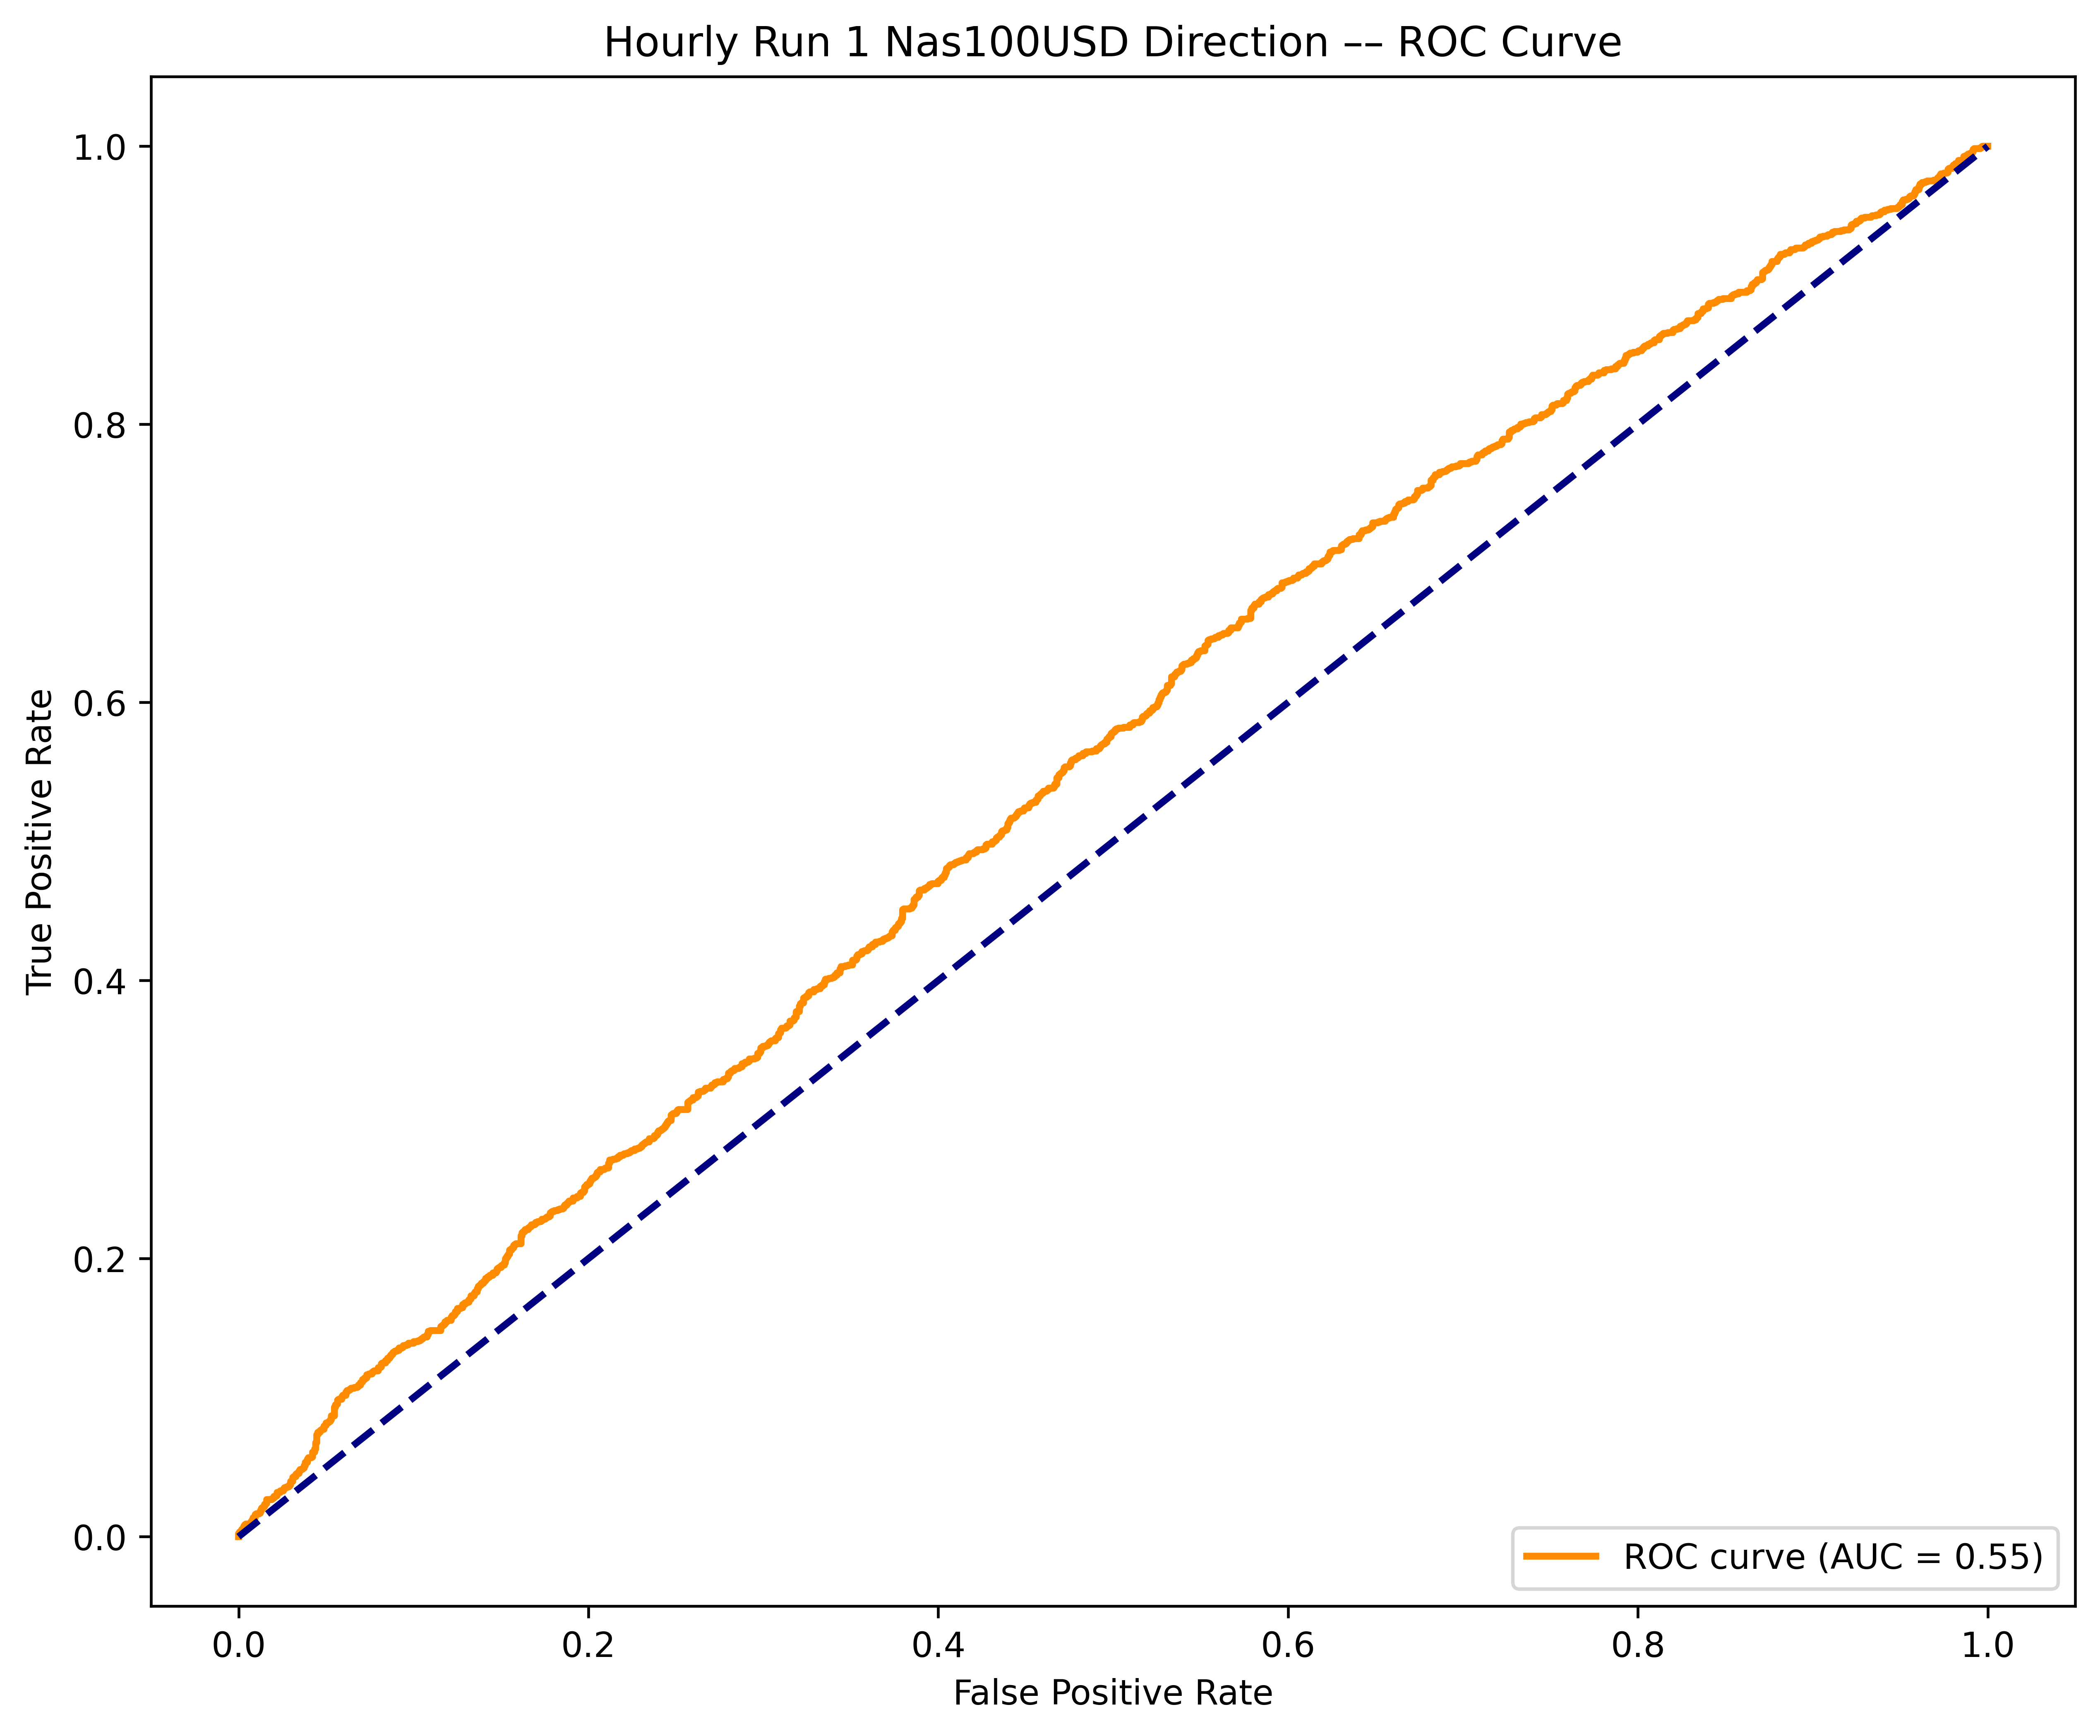

[CV] END classifier__max_depth=4, classifier__n_estimators=2000; total time= 3.4min
[CV] END classifier__max_depth=5, classifier__n_estimators=4000; total time= 4.6min
[CV] END classifier__max_depth=4, classifier__n_estimators=2000; total time= 1.7min
[CV] END classifier__max_depth=4, classifier__n_estimators=4000; total time= 6.7min
[CV] END classifier__max_depth=3, classifier__n_estimators=4000; total time= 4.1min
[CV] END classifier__max_depth=5, classifier__n_estimators=4000; total time= 5.6min
[CV] END classifier__max_depth=4, classifier__n_estimators=2000; total time= 4.2min
[CV] END classifier__max_depth=5, classifier__n_estimators=4000; total time= 6.7min


In [7]:
intervals_lookback = 23

target_col = 'bullish' #'low_proportion_of_interval'#'interval_return' #'high_proportion_of_day'#'high_hour_of_day' #'bullish' #'high_hour_of_day' # Colud be any of the End of Periood Columns

x_test, x_train, y_test, y_train, categorical_features, numeric_features = getFeatureEngineeredTestTrainData(df_hourly, descriptive_cols, end_of_period_num_cols, end_of_period_cat_cols, target_col, intervals_lookback)

preprocessorRF = ColumnTransformer(
    transformers=[
        # ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan), categorical_features),
        # ('num', StandardScaler(), numeric_features) 
    ],
    remainder='passthrough'  # This keeps the remaining columns (numeric) as they are
)

# Define hyperparameters to tune during cross-validation
param_grid = {
    'classifier__n_estimators': [2000, 4000],  # Number of trees
    # 'classifier__learning_rate': [0.0077, 0.008, 0.0082],  # Learning rate
    'classifier__max_depth': [3, 4, 5],  # Maximum depth of trees
    # 'classifier__min_child_weight':range(1,6,2)
}
feature_cols = categorical_features + numeric_features

grid_search = create_RF_CLF_GridSearch(intervals_lookback, preprocessorRF, param_grid)

clf = runRFGridSearch(grid_search, x_train, y_train, x_test, y_test, feature_cols, label='Hourly Run 1')  

In [142]:
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Perceptron
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import RFE, RFECV
from numpy import mean
from numpy import std
# define dataset
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, n_redundant=5, random_state=1)
# create pipeline
rfe = RFECV(estimator=DecisionTreeClassifier())
model = DecisionTreeClassifier()
pipeline = Pipeline(steps=[('s',rfe),('m',model)])
# evaluate model
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
n_scores = cross_val_score(pipeline, X, y, scoring='accuracy', cv=cv, n_jobs=-1, error_score='raise')
grid_results = GridSearchCV(pipeline,None, cv=tscv, scoring='accuracy', verbose=2, n_jobs=-2) 
# report performance
print('Accuracy: %.3f (%.3f)' % (mean(n_scores), std(n_scores)))

Accuracy: 0.887 (0.027)


In [ ]:

rfe = RFECV(estimator=RandomForestClassifier())
pipelineRF = Pipeline(steps=[
        ('rfe', rfe),  # Apply the preprocessor
        ('classifier', clf)        # Apply the RF model
    ])

param_grid = {
        'classifier__n_estimators': [300],  # Number of trees
        'classifier__max_depth': [20, 50],  # Maximum depth of trees
        'classifier__max_features': ['log2', 'sqrt', 10, 100],
        'classifier__min_samples_leaf': [1, 4],
        'classifier__min_samples_split': [2, 10],
        }
tscv = TimeSeriesSplit(n_splits=5, gap=intervals_lookback+1)
clf = RandomForestClassifier(random_state=0) #, class_weight='balanced_subsample')

grid_search = GridSearchCV(pipelineRF, param_grid, cv=tscv, scoring='f1', verbose=2, n_jobs=-2) # roc_auc,n_jobs=-4 'neg_mean_absolute_error' roc_auc_ovo_weighted f1
clf = runRFGridSearch(grid_search, x_train, y_train, x_test, y_test, feature_cols, label='Hourly Run rfe')    

Fitting 5 folds for each of 32 candidates, totalling 160 fits


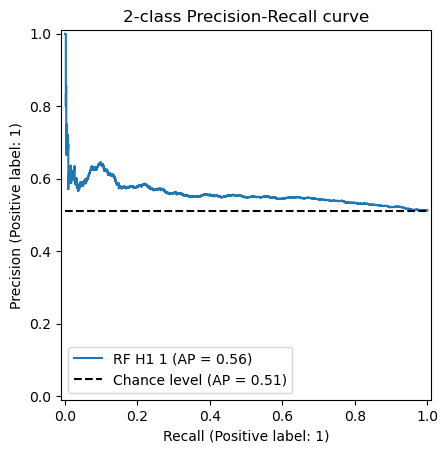

In [121]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay
# y_true = np.array([0, 0, 1, 1])
# y_scores = np.array([0.1, 0.4, 0.35, 0.8])
# precision, recall, thresholds = precision_recall_curve(
#     y_true, y_scores)

y_pred_proba = clf.predict_proba(x_test.values)

display = PrecisionRecallDisplay.from_predictions(
    y_test, y_pred_proba[:,1], name="RF H1 1", plot_chance_level=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")

# display = PrecisionRecallDisplay.from_predictions(
#     y_test, y_pred_proba[:,0], name="RF H1 0", plot_chance_level=True
# )
# _ = display.ax_.set_title("2-class Precision-Recall curve")

In [129]:
from sklearn.model_selection import TunedThresholdClassifierCV, cross_validate
data = x_test
target = y_test
tscv = TimeSeriesSplit(n_splits=5, gap=intervals_lookback+1)

scoring = ["accuracy", "f1"]
cv_scores = [
    "train_accuracy",
    "test_accuracy",
    "train_f1",
    "test_f1",
]

cv_results_vanilla_model = pd.DataFrame(
    cross_validate(
        clf,
        data,
        target,
        scoring=scoring,
        cv=tscv,
        return_train_score=True,
        return_estimator=True,
    )
)
cv_results_vanilla_model[cv_scores].aggregate(["mean", "std"]).T



,mean,std
train_accuracy,0.825091,0.103243
test_accuracy,0.518325,0.014232
train_f1,0.850884,0.079932
test_f1,0.584446,0.027579


In [130]:
tuned_model = TunedThresholdClassifierCV(estimator=clf, scoring="balanced_accuracy")
cv_results_tuned_model = pd.DataFrame(
    cross_validate(
        tuned_model,
        data,
        target,
        scoring=scoring,
        cv=tscv,
        return_train_score=True,
        return_estimator=True
    )
)
cv_results_tuned_model[cv_scores].aggregate(["mean", "std"]).T

,mean,std
train_accuracy,0.674393,0.118695
test_accuracy,0.497731,0.014146
train_f1,0.650440,0.173630
test_f1,0.430184,0.246495


In [131]:
import matplotlib.pyplot as plt

vanilla_model_coef = pd.DataFrame(
    [est[-1].coef_.ravel() for est in cv_results_vanilla_model["estimator"]],
    columns=diabetes.feature_names,
)
tuned_model_coef = pd.DataFrame(
    [est.estimator_[-1].coef_.ravel() for est in cv_results_tuned_model["estimator"]],
    columns=diabetes.feature_names,
)

fig, ax = plt.subplots(ncols=2, figsize=(12, 4), sharex=True, sharey=True)
vanilla_model_coef.boxplot(ax=ax[0])
ax[0].set_ylabel("Coefficient value")
ax[0].set_title("Vanilla model")
tuned_model_coef.boxplot(ax=ax[1])
ax[1].set_title("Tuned model")
_ = fig.suptitle("Coefficients of the predictive models")

AttributeError: 'DecisionTreeClassifier' object has no attribute 'coef_'

In [16]:
x_train.columns.values

array(['quarter_of_year', 'month_of_year', 'week_of_year', ...,
       'cl_interval_range_ratio23', 'cl_interval_return_ratio23',
       'cl_ATR_ratio23'], dtype=object)